# Data Preprocessing

## Steps
### 1. Handling Missing Data
### 2. Outlier Removal
### 3. Encoding
#### ------I.  Label Encoding
#### ------II. Onehot Encoding
### 4. Scaling
#### ------I.  Normalization
#### ------II. Standardization
### 5. Feature Selection

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Read Dataset

In [2]:
# Load the dataset
data = pd.read_csv('loan_data_balanced (2).xls')

data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0.0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561.0,No,Accepted
1,21.0,female,High School,12282.0,0.0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504.0,Yes,Rejected
2,25.0,female,High School,12438.0,3.0,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635.0,No,Accepted
3,23.0,female,Bachelor,79753.0,0.0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675.0,No,Accepted
4,24.0,male,Master,66135.0,1.0,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586.0,No,Accepted


In [3]:
#shape
data.shape

(70000, 14)

In [4]:
#info()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      70000 non-null  float64
 1   person_gender                   70000 non-null  object 
 2   person_education                70000 non-null  object 
 3   person_income                   70000 non-null  float64
 4   person_emp_exp                  70000 non-null  float64
 5   person_home_ownership           70000 non-null  object 
 6   loan_amnt                       70000 non-null  float64
 7   loan_intent                     70000 non-null  object 
 8   loan_int_rate                   70000 non-null  float64
 9   loan_percent_income             70000 non-null  float64
 10  cb_person_cred_hist_length      70000 non-null  float64
 11  credit_score                    70000 non-null  float64
 12  previous_loan_defaults_on_file  

# Step 01: Handling Missing Data

In [5]:
#finding missing values
data.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [6]:
#finding duplicates
dup_count = data.duplicated().sum()
print("Number of duplicate rows:", dup_count)

Number of duplicate rows: 0


## Data Analysis

In [7]:
#descriptive statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,70000.0,27.663017,6.053506,18.900141,23.528401,26.000000,30.000000,1.440000e+02
person_income,70000.0,72913.295394,70559.954823,7213.539091,41782.762737,61036.000000,87496.000000,7.200766e+06
person_emp_exp,70000.0,5.309844,5.992026,0.000000,1.000000,3.876512,8.000000,1.250000e+02
loan_amnt,70000.0,10062.261703,6667.748929,500.000000,5000.000000,8500.000000,13947.457659,3.846680e+04
loan_int_rate,70000.0,11.670936,3.168750,4.916521,9.620000,11.460000,13.944960,2.199775e+01
loan_percent_income,70000.0,0.162547,0.099758,0.000000,0.080000,0.140000,0.230000,6.600000e-01
cb_person_cred_hist_length,70000.0,5.821162,3.882467,1.800035,3.000000,4.066065,8.000000,3.295768e+01
credit_score,70000.0,632.571749,55.006057,388.871823,597.807029,638.000000,671.855383,8.500000e+02


In [8]:
data.describe(include="object")

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file,loan_status
count,70000,70000,70000,70000,70000,70000
unique,2,5,4,6,2,2
top,male,Bachelor,RENT,EDUCATION,No,Accepted
freq,37218,18424,29630,13359,47142,35000


# Step 02: Outlier Treatments

## Before

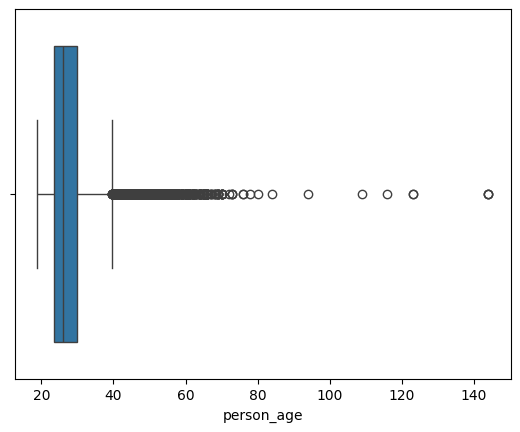

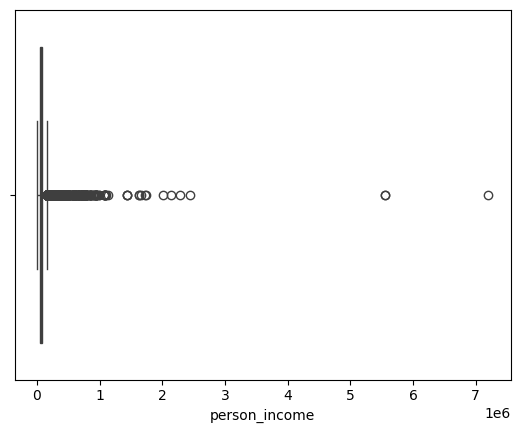

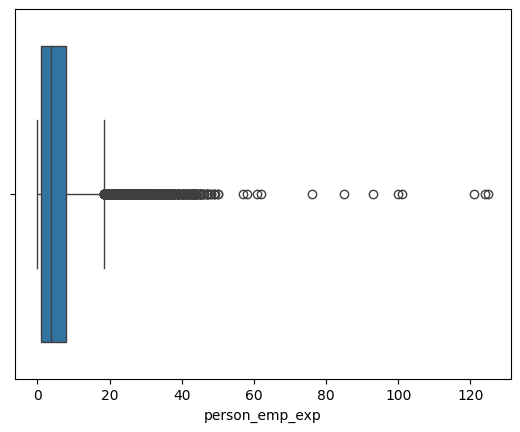

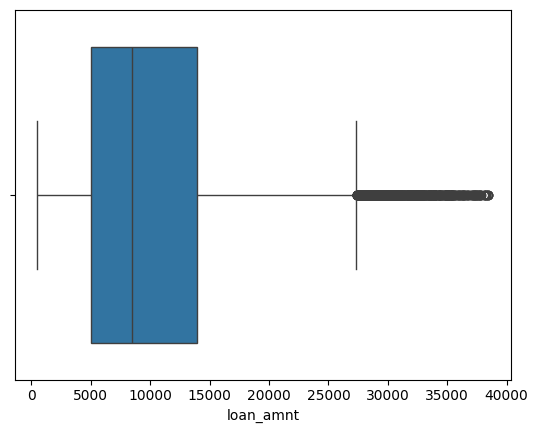

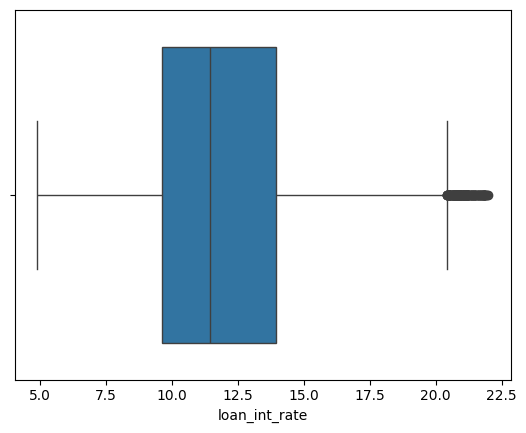

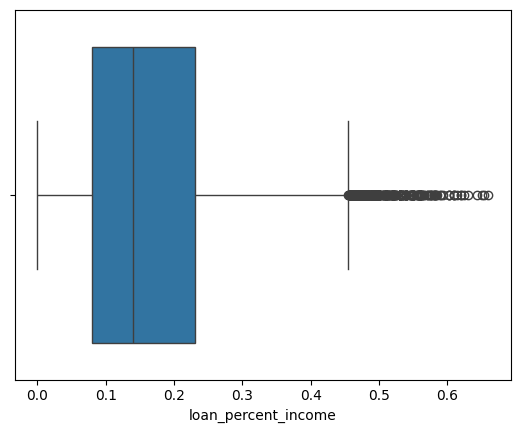

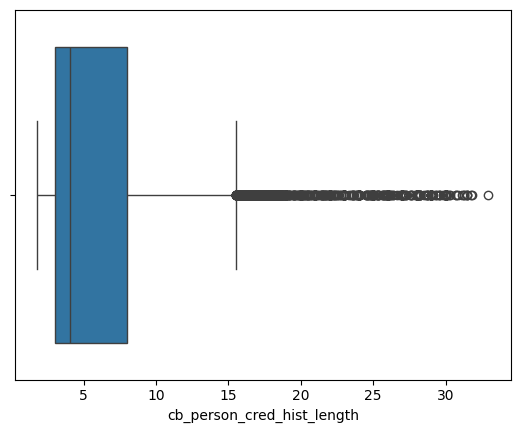

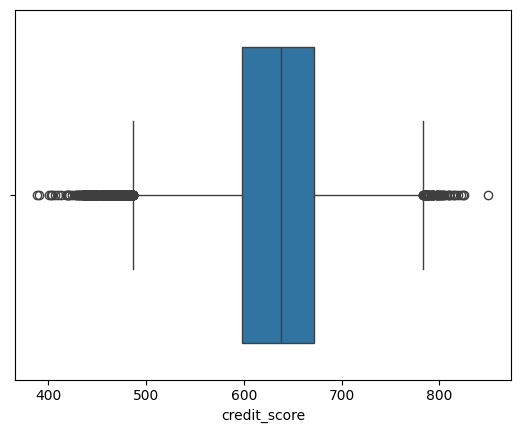

In [9]:
#Boxplot-to-identify outliers
for i in data.select_dtypes(include="number").columns:
    sns.boxplot(data = data, x = i)
    plt.show()
    plt.close()

## After

In [10]:
#decide wheather to do outliers treatment or not

In [11]:
def wisker(col):
    q1,q3=np.percentile(col, [25,75])
    iqr=q3-q1
    lw = q1-1.5*iqr
    uw = q3+1.5*iqr
    return lw,uw

In [12]:
wisker(data['credit_score'])

(np.float64(486.7344974121478), np.float64(782.927914292667))

In [13]:
for i in ['credit_score','person_age','person_income','person_emp_exp','loan_amnt','loan_int_rate','loan_percent_income', 'cb_person_cred_hist_length',]:
    lw,uw=wisker(data[i])
    data[i]=np.where(data[i]<lw,lw,data[i])
    data[i]=np.where(data[i]>uw,uw,data[i])

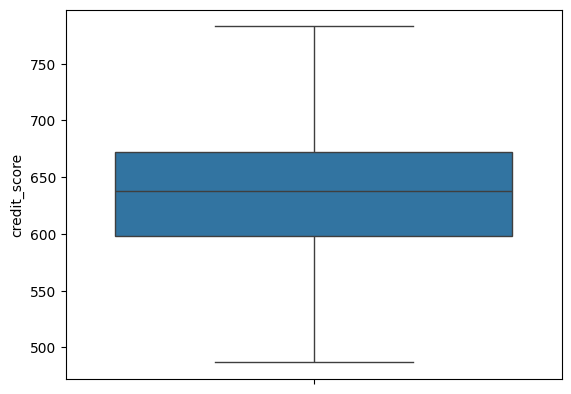

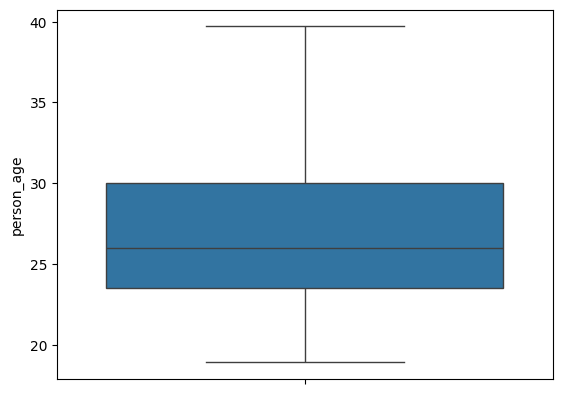

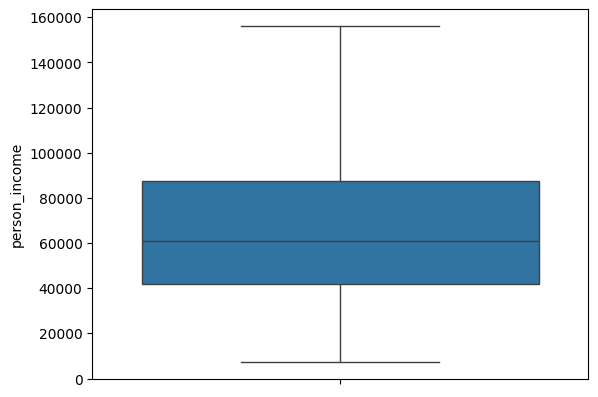

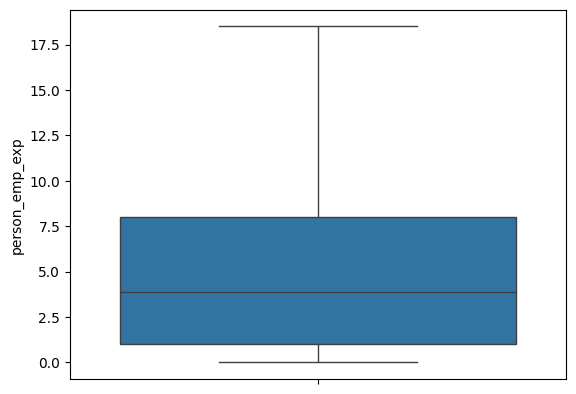

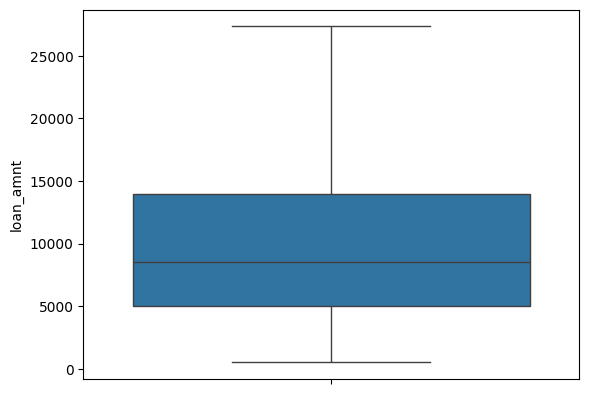

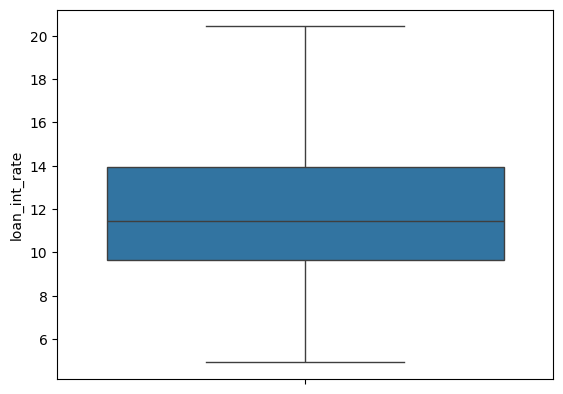

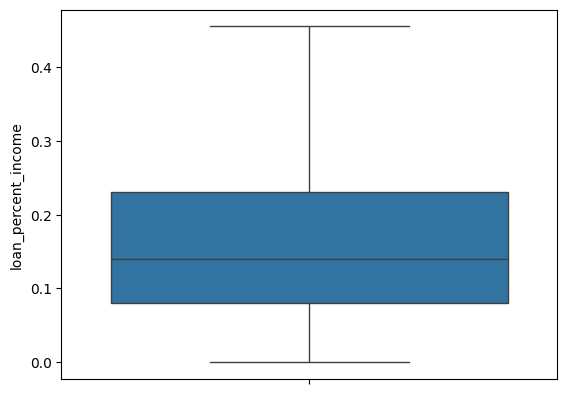

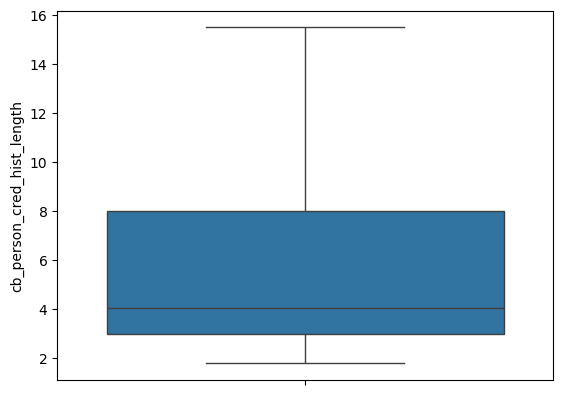

In [14]:
for i in ['credit_score','person_age','person_income','person_emp_exp','loan_amnt','loan_int_rate','loan_percent_income', 'cb_person_cred_hist_length',]:
    sns.boxplot(data[i])
    plt.show()
    plt.close()

# Step 03: Encoding

In [15]:
data

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.000000,female,Master,71948.000000,0.000000,RENT,27368.644148,PERSONAL,16.020000,0.455000,3.000000,561.000000,No,Accepted
1,21.000000,female,High School,12282.000000,0.000000,OWN,1000.000000,EDUCATION,11.140000,0.080000,2.000000,504.000000,Yes,Rejected
2,25.000000,female,High School,12438.000000,3.000000,MORTGAGE,5500.000000,MEDICAL,12.870000,0.440000,3.000000,635.000000,No,Accepted
3,23.000000,female,Bachelor,79753.000000,0.000000,RENT,27368.644148,MEDICAL,15.230000,0.440000,2.000000,675.000000,No,Accepted
4,24.000000,male,Master,66135.000000,1.000000,RENT,27368.644148,MEDICAL,14.270000,0.455000,4.000000,586.000000,No,Accepted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,26.059970,male,Associate,34029.461589,1.011483,RENT,11570.099432,HOMEIMPROVEMENT,8.445734,0.353799,4.064910,626.608678,No,Accepted
69996,30.911187,male,High School,32347.796692,10.245725,OWN,2429.455938,PERSONAL,20.304310,0.065633,9.457529,584.041298,No,Accepted
69997,22.540832,female,Doctorate,39139.490706,0.000000,OWN,3286.620674,DEBTCONSOLIDATION,8.590706,0.083773,3.184808,654.620240,No,Accepted
69998,28.650949,male,Associate,18557.682938,8.126166,OTHER,4357.506077,DEBTCONSOLIDATION,11.662150,0.211830,5.426057,633.508816,No,Accepted


## I. Label Encoding

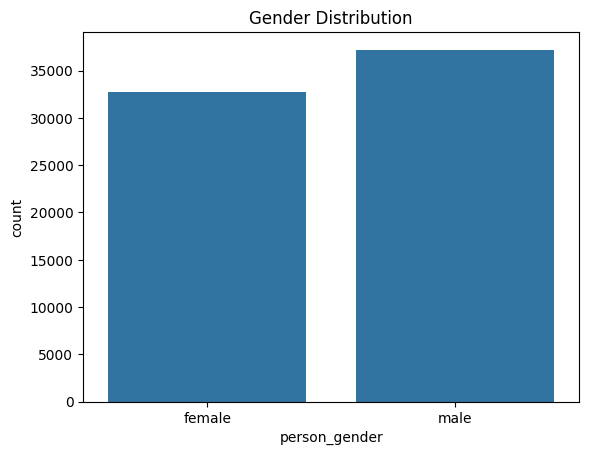

In [16]:
# Before label encoding
sns.countplot(x="person_gender", data=data)
plt.title("Gender Distribution")
plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['person_gender'] = le.fit_transform(data['person_gender'])
data['previous_loan_defaults_on_file'] = le.fit_transform(data['previous_loan_defaults_on_file'])
data['loan_status'] = le.fit_transform(data['loan_status'])

In [18]:
data

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.000000,0,Master,71948.000000,0.000000,RENT,27368.644148,PERSONAL,16.020000,0.455000,3.000000,561.000000,0,0
1,21.000000,0,High School,12282.000000,0.000000,OWN,1000.000000,EDUCATION,11.140000,0.080000,2.000000,504.000000,1,1
2,25.000000,0,High School,12438.000000,3.000000,MORTGAGE,5500.000000,MEDICAL,12.870000,0.440000,3.000000,635.000000,0,0
3,23.000000,0,Bachelor,79753.000000,0.000000,RENT,27368.644148,MEDICAL,15.230000,0.440000,2.000000,675.000000,0,0
4,24.000000,1,Master,66135.000000,1.000000,RENT,27368.644148,MEDICAL,14.270000,0.455000,4.000000,586.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,26.059970,1,Associate,34029.461589,1.011483,RENT,11570.099432,HOMEIMPROVEMENT,8.445734,0.353799,4.064910,626.608678,0,0
69996,30.911187,1,High School,32347.796692,10.245725,OWN,2429.455938,PERSONAL,20.304310,0.065633,9.457529,584.041298,0,0
69997,22.540832,0,Doctorate,39139.490706,0.000000,OWN,3286.620674,DEBTCONSOLIDATION,8.590706,0.083773,3.184808,654.620240,0,0
69998,28.650949,1,Associate,18557.682938,8.126166,OTHER,4357.506077,DEBTCONSOLIDATION,11.662150,0.211830,5.426057,633.508816,0,0


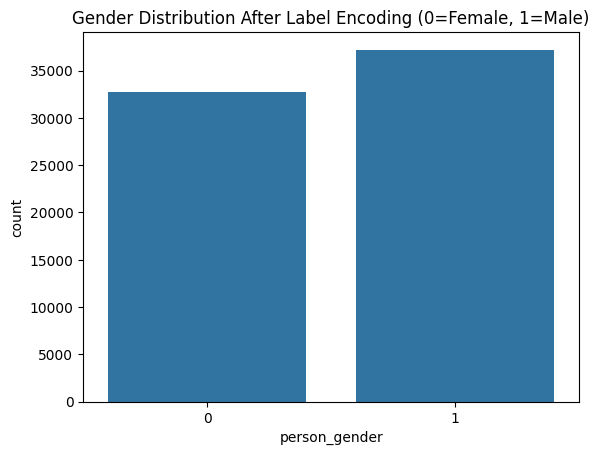

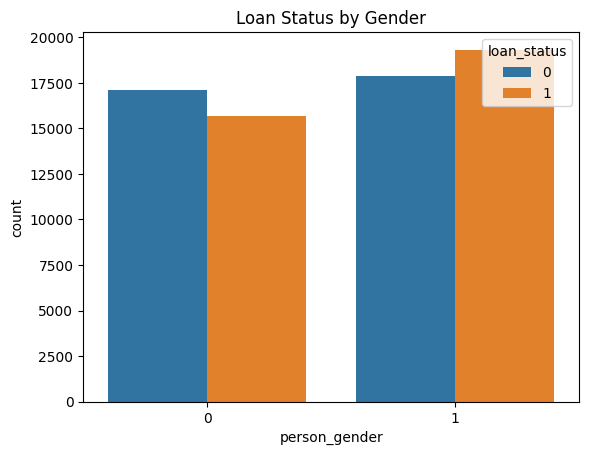

In [19]:
# After label encoding
sns.countplot(x="person_gender", data=data)
plt.title("Gender Distribution After Label Encoding (0=Female, 1=Male)")
plt.show()

pd.crosstab(data['person_gender'], data['loan_status'])

sns.countplot(x="person_gender", hue="loan_status", data=data)
plt.title("Loan Status by Gender")
plt.show()

## II. Onehot Encoding

### Before

In [20]:
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,Master,71948.0,0.0,RENT,27368.644148,PERSONAL,16.02,0.455,3.0,561.0,0,0
1,21.0,0,High School,12282.0,0.0,OWN,1000.000000,EDUCATION,11.14,0.080,2.0,504.0,1,1
2,25.0,0,High School,12438.0,3.0,MORTGAGE,5500.000000,MEDICAL,12.87,0.440,3.0,635.0,0,0
3,23.0,0,Bachelor,79753.0,0.0,RENT,27368.644148,MEDICAL,15.23,0.440,2.0,675.0,0,0
4,24.0,1,Master,66135.0,1.0,RENT,27368.644148,MEDICAL,14.27,0.455,4.0,586.0,0,0


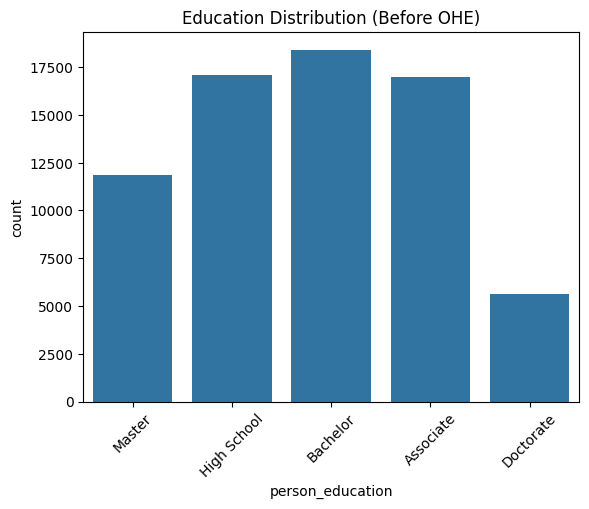

In [21]:
# 1. Education distribution
sns.countplot(x="person_education", data=data)
plt.title("Education Distribution (Before OHE)")
plt.xticks(rotation=45)
plt.show()

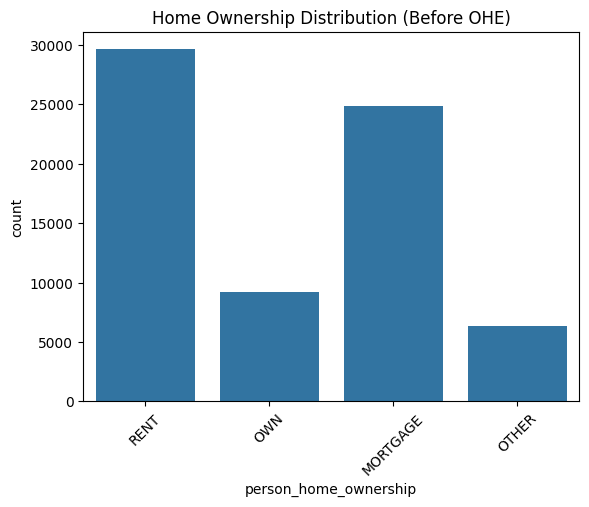

In [22]:
# 2. Home ownership distribution
sns.countplot(x="person_home_ownership", data=data)
plt.title("Home Ownership Distribution (Before OHE)")
plt.xticks(rotation=45)
plt.show()

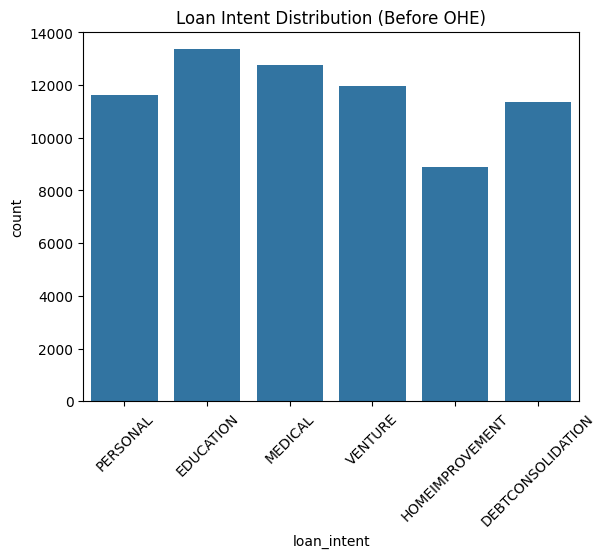

In [23]:
# 3. Loan intent distribution
sns.countplot(x="loan_intent", data=data)
plt.title("Loan Intent Distribution (Before OHE)")
plt.xticks(rotation=45)
plt.show()

## Encoding

In [24]:
data['person_education'].unique()

array(['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate'],
      dtype=object)

In [25]:
categorical_cols = ['person_education', 'person_home_ownership', 'loan_intent']

from sklearn.preprocessing import OneHotEncoder
oh = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
ohtransform = oh.fit_transform(data[categorical_cols])

In [26]:
ohtransform

,person_education_Associate,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
69996,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
69997,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
69998,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [27]:
data = pd.concat([data, ohtransform], axis=1).drop(columns = ['person_education', 'person_home_ownership', 'loan_intent'])

In [28]:
data

,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,...,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.000000,0,71948.000000,0.000000,27368.644148,16.020000,0.455000,3.000000,561.000000,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,21.000000,0,12282.000000,0.000000,1000.000000,11.140000,0.080000,2.000000,504.000000,1,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,25.000000,0,12438.000000,3.000000,5500.000000,12.870000,0.440000,3.000000,635.000000,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,23.000000,0,79753.000000,0.000000,27368.644148,15.230000,0.440000,2.000000,675.000000,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,24.000000,1,66135.000000,1.000000,27368.644148,14.270000,0.455000,4.000000,586.000000,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,26.059970,1,34029.461589,1.011483,11570.099432,8.445734,0.353799,4.064910,626.608678,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
69996,30.911187,1,32347.796692,10.245725,2429.455938,20.304310,0.065633,9.457529,584.041298,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
69997,22.540832,0,39139.490706,0.000000,3286.620674,8.590706,0.083773,3.184808,654.620240,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
69998,28.650949,1,18557.682938,8.126166,4357.506077,11.662150,0.211830,5.426057,633.508816,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### After

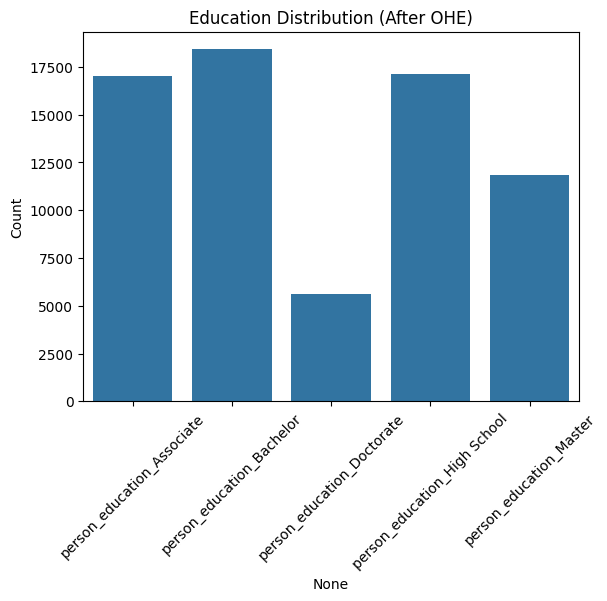

In [29]:
# 1. Education distribution after OHE
edu_cols = [col for col in data.columns if col.startswith("person_education_")]
sns.barplot(x=data[edu_cols].sum().index,
            y=data[edu_cols].sum().values)
plt.title("Education Distribution (After OHE)")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

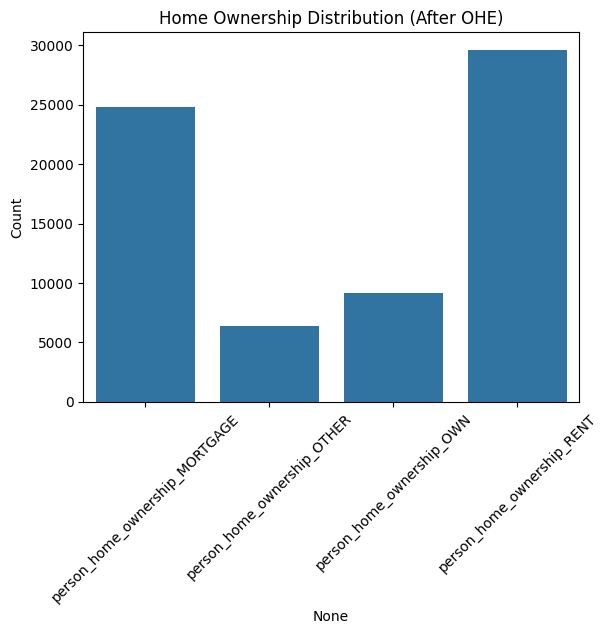

In [30]:
# 2. Home ownership distribution after OHE
home_cols = [col for col in data.columns if col.startswith("person_home_ownership_")]
sns.barplot(x=data[home_cols].sum().index,
            y=data[home_cols].sum().values)
plt.title("Home Ownership Distribution (After OHE)")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

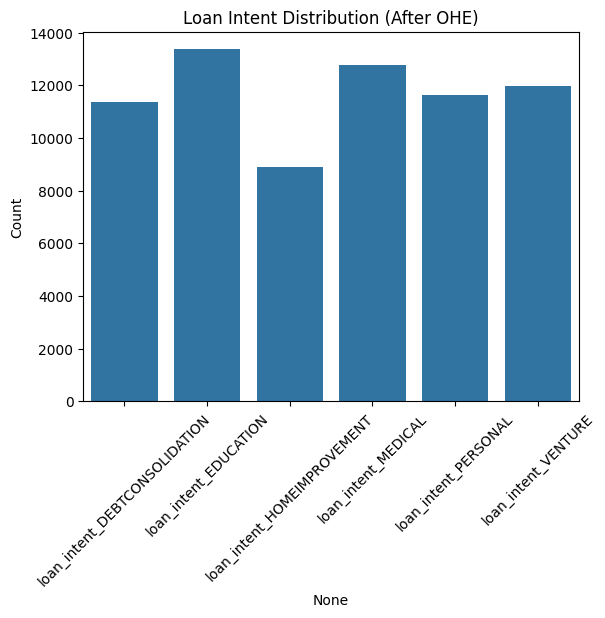

In [31]:
# 3. Loan intent distribution after OHE
loan_cols = [col for col in data.columns if col.startswith("loan_intent_")]
sns.barplot(x=data[loan_cols].sum().index,
            y=data[loan_cols].sum().values)
plt.title("Loan Intent Distribution (After OHE)")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

# Step 04: Scaling

## I. Normalization

In [32]:
from sklearn.preprocessing import MinMaxScaler

# Define numerical columns to scale
num_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 
            'credit_score']

# Initialize and apply scaler
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(data[num_cols]), columns=num_cols)

df_scaled

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
0,0.148980,0.434891,0.000000,1.000000,0.715620,1.000000,0.087589,0.250733
1,0.100920,0.034050,0.000000,0.018609,0.401104,0.175824,0.014596,0.058291
2,0.293160,0.035098,0.162162,0.186091,0.512603,0.967033,0.087589,0.500570
3,0.197040,0.487325,0.000000,1.000000,0.664705,0.967033,0.014596,0.635617
4,0.245100,0.395838,0.054054,1.000000,0.602833,1.000000,0.160582,0.335137
...,...,...,...,...,...,...,...,...
69995,0.344102,0.180151,0.054675,0.412008,0.227458,0.777581,0.165320,0.472239
69996,0.577253,0.168854,0.553823,0.071811,0.991745,0.144248,0.558943,0.328525
69997,0.174972,0.214481,0.000000,0.103713,0.236802,0.184117,0.101079,0.566811
69998,0.468625,0.076211,0.439252,0.143569,0.434756,0.465561,0.264674,0.495535


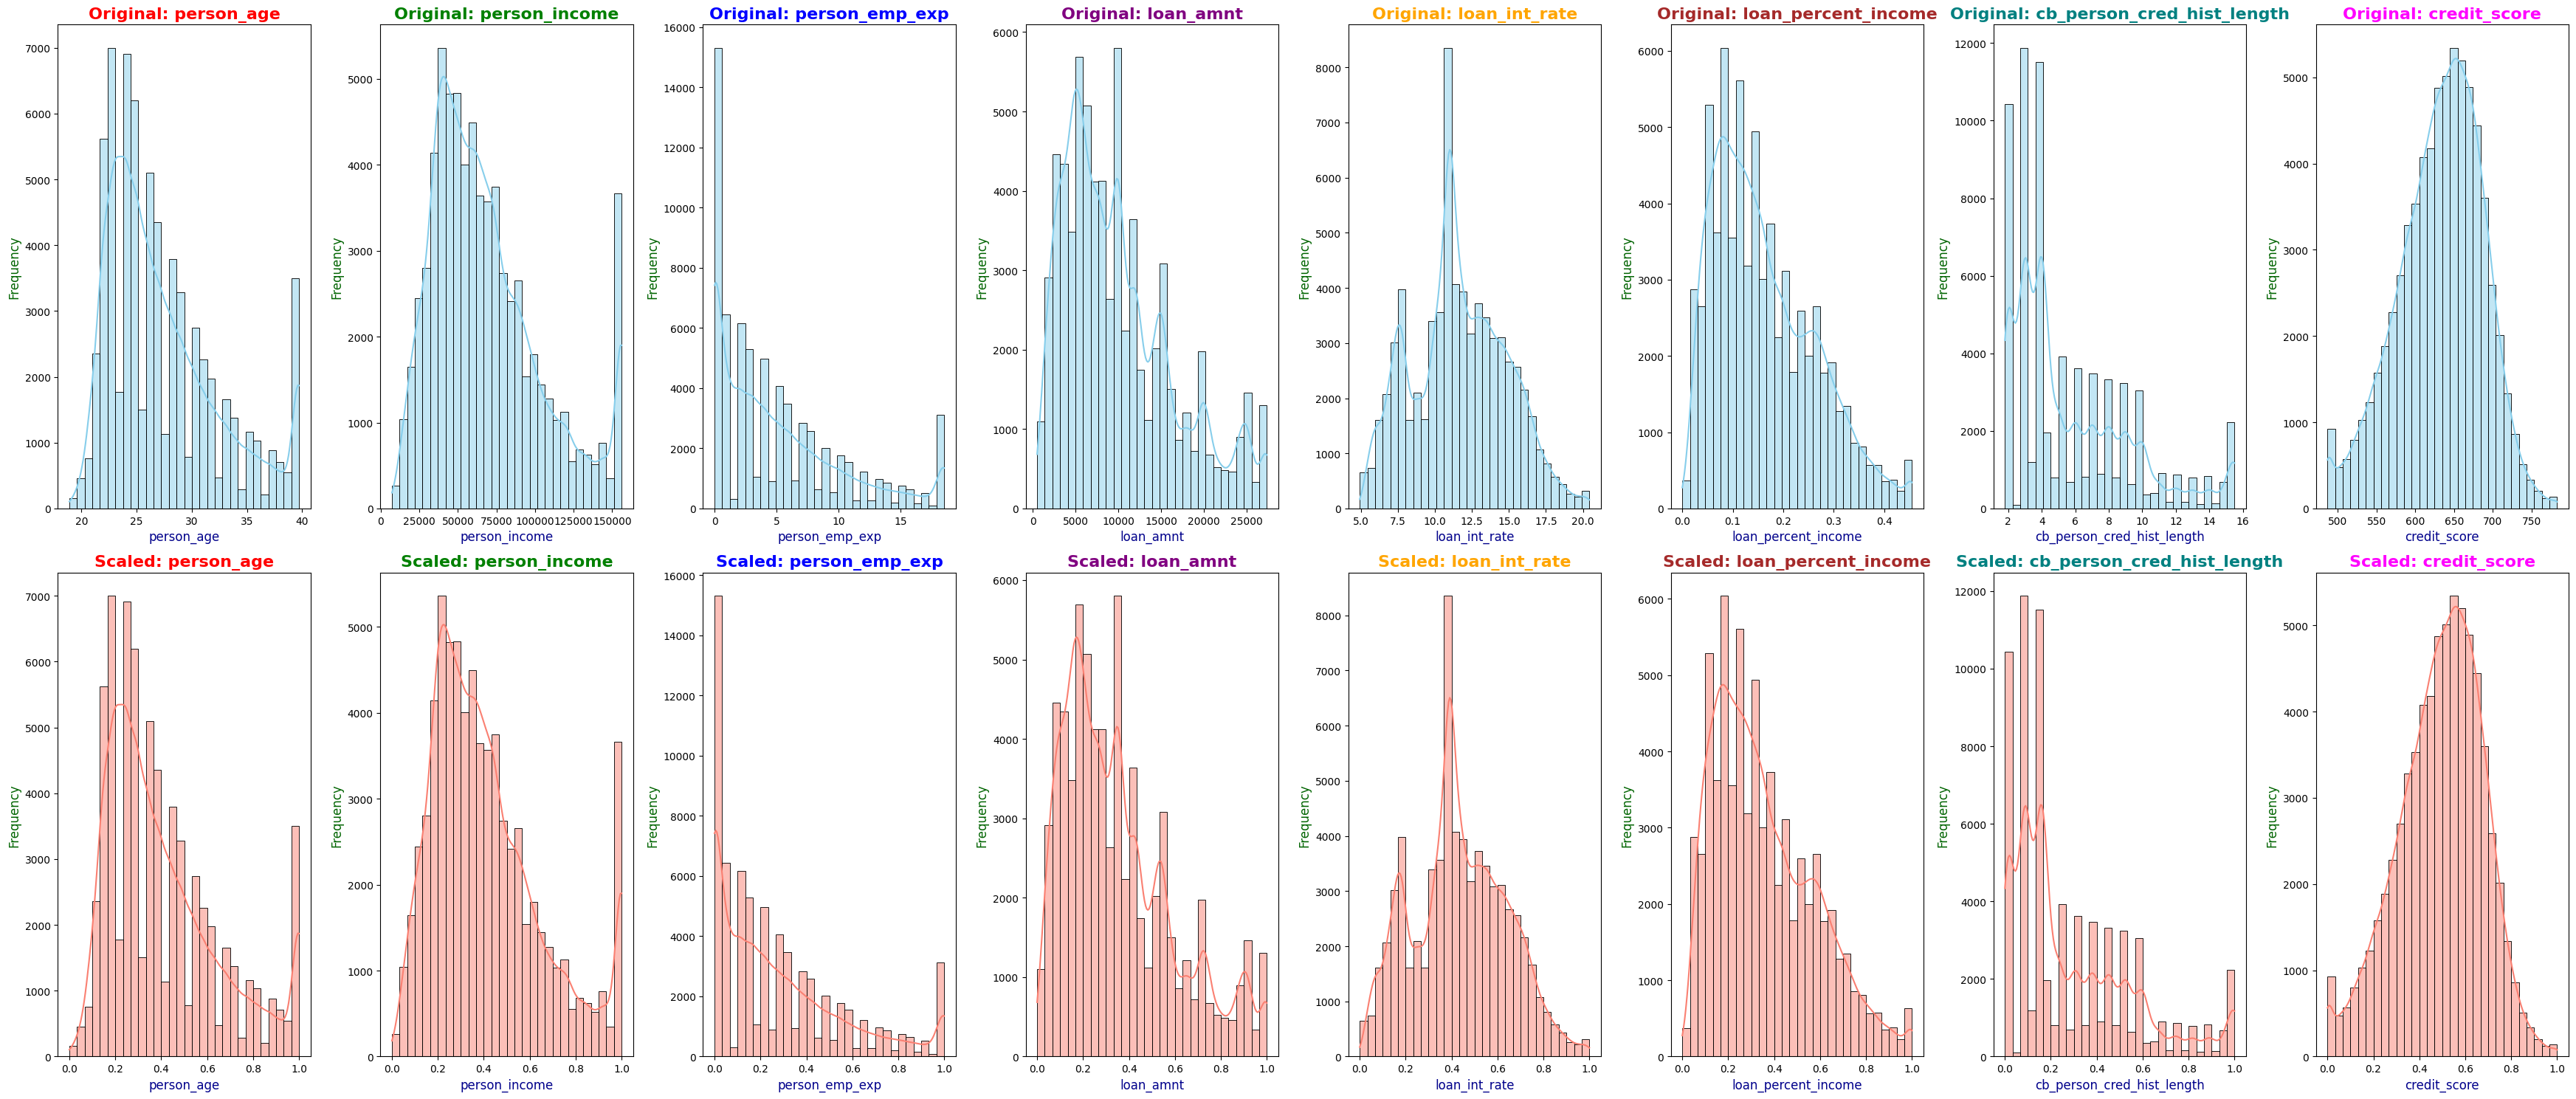

In [33]:
# Create large figure with subplots
fig, axes = plt.subplots(nrows=2, ncols=len(num_cols), figsize=(35,15))

# Define colors for titles
colors = ["red", "green", "blue", "purple", "orange", "brown", "teal", "magenta"]

for i, col in enumerate(num_cols):
    # Original distribution
    sns.histplot(data[col], bins=30, ax=axes[0,i], kde=True, color="skyblue")
    axes[0,i].set_title(f"Original: {col}", fontsize=16, color=colors[i], fontweight="bold")
    axes[0,i].set_xlabel(col, fontsize=12, color="darkblue")
    axes[0,i].set_ylabel("Frequency", fontsize=12, color="darkgreen")
    
    # Scaled distribution
    sns.histplot(df_scaled[col], bins=30, ax=axes[1,i], kde=True, color="salmon")
    axes[1,i].set_title(f"Scaled: {col}", fontsize=16, color=colors[i], fontweight="bold")
    axes[1,i].set_xlabel(col, fontsize=12, color="darkblue")
    axes[1,i].set_ylabel("Frequency", fontsize=12, color="darkgreen")

# Adjust spacing
plt.tight_layout()
plt.show()
plt.close()


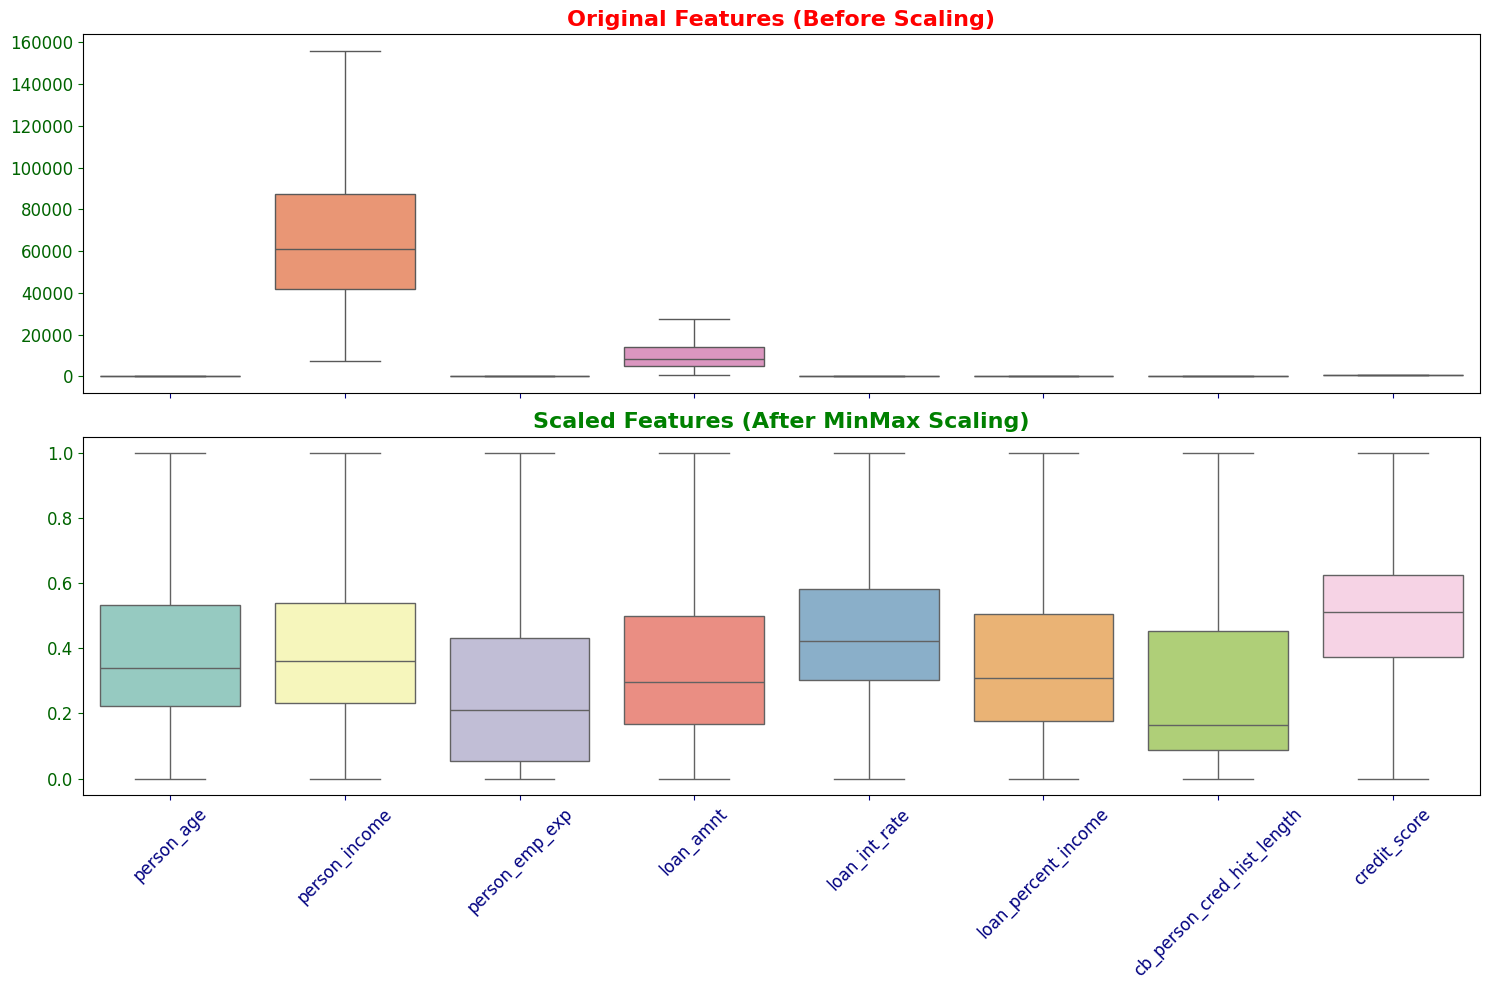

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15,10), sharex=True)

# Original Data
sns.boxplot(data=data[num_cols], ax=axes[0], palette="Set2")
axes[0].set_title("Original Features (Before Scaling)", fontsize=16, color="red", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45, labelsize=12, colors="navy")
axes[0].tick_params(axis="y", labelsize=12, colors="darkgreen")

# Scaled Data
sns.boxplot(data=df_scaled[num_cols], ax=axes[1], palette="Set3")
axes[1].set_title("Scaled Features (After MinMax Scaling)", fontsize=16, color="green", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=12, colors="navy")
axes[1].tick_params(axis="y", labelsize=12, colors="darkgreen")

plt.tight_layout()
plt.show()
plt.close()

## II. Standardization

In [35]:
# Identify the Target Variable
Target_column = "loan_status"
Y = data[Target_column]
X = data.drop(columns=[Target_column])

from sklearn.preprocessing import StandardScaler

num_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 
            'credit_score']

In [36]:
sc = StandardScaler()

In [37]:
standardization = pd.DataFrame(sc.fit_transform(data[num_cols]), columns=num_cols)

In [38]:
standardization

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
0,-1.063090,0.090144,-0.992834,2.690018,1.374443,2.963260,-0.766368,-1.316769
1,-1.260724,-1.577853,-0.992834,-1.392827,-0.167355,-0.832673,-1.046620,-2.363192
2,-0.470189,-1.573492,-0.405884,-0.696060,0.379225,2.811423,-0.766368,0.041744
3,-0.865457,0.308338,-0.992834,2.690018,1.124848,2.811423,-1.046620,0.776076
4,-0.667823,-0.072361,-0.797184,2.690018,0.821544,2.963260,-0.486115,-0.857812
...,...,...,...,...,...,...,...,...
69995,-0.260703,-0.969890,-0.794938,0.243817,-1.018588,1.938856,-0.467924,-0.112306
69996,0.698062,-1.016902,1.011742,-1.171494,2.728037,-0.978105,1.043371,-0.893771
69997,-0.956204,-0.827037,-0.992834,-1.038773,-0.972785,-0.794477,-0.714575,0.401938
69998,0.251362,-1.402413,0.597050,-0.872960,-0.002386,0.501778,-0.086459,0.014368


In [39]:
#Graphs
def plots(df, var, t):
    plt.figure(figsize=(13,5))
    plt.subplot(121)
    sns.kdeplot(df[var])
    plt.title('Before ' + str(t).split('(')[0])

    plt.subplot(122)
    p1 = t.fit_transform(df[[var]]).flatten()
    sns.kdeplot(p1)
    plt.title('After ' + str(t).split('(')[0])
    plt.show()
    plt.close()    

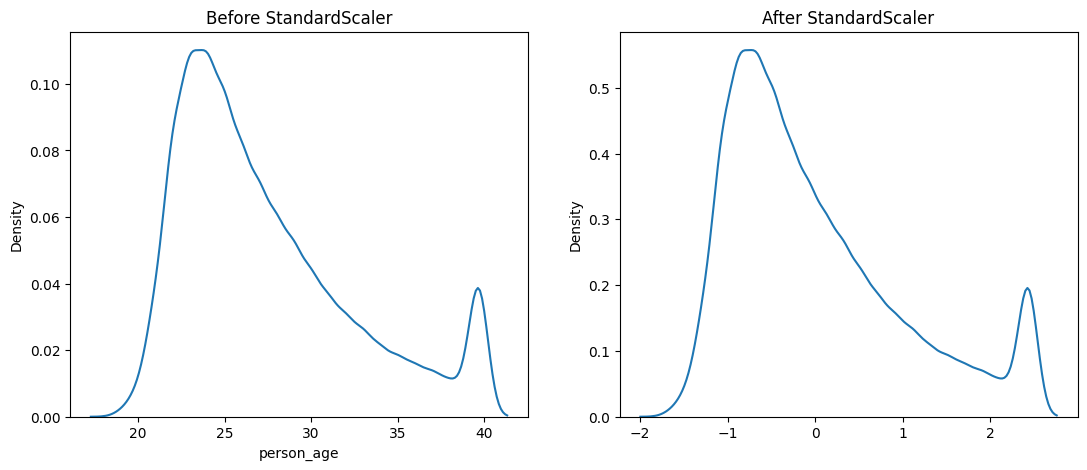

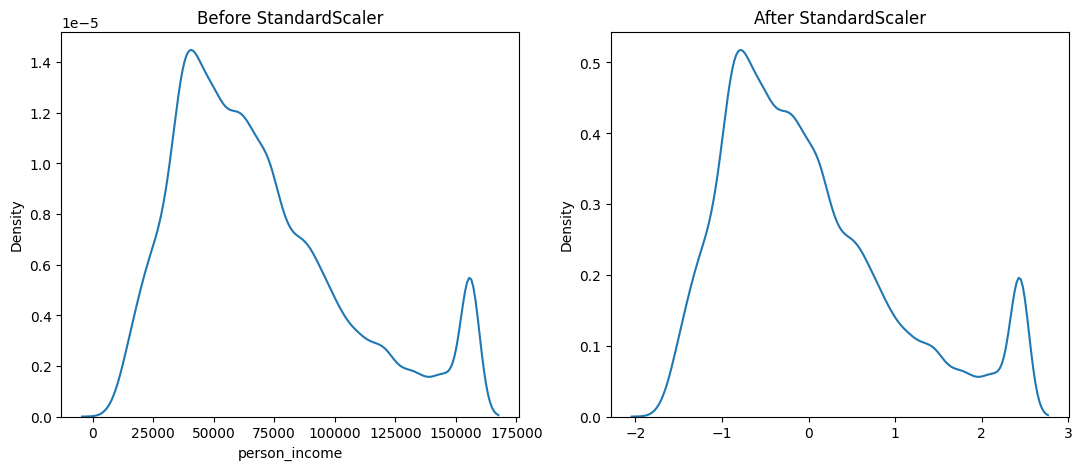

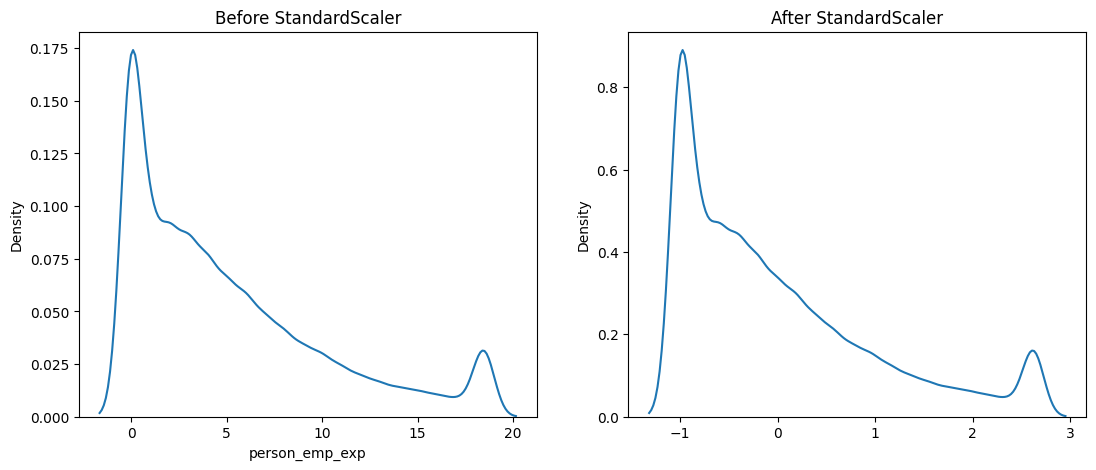

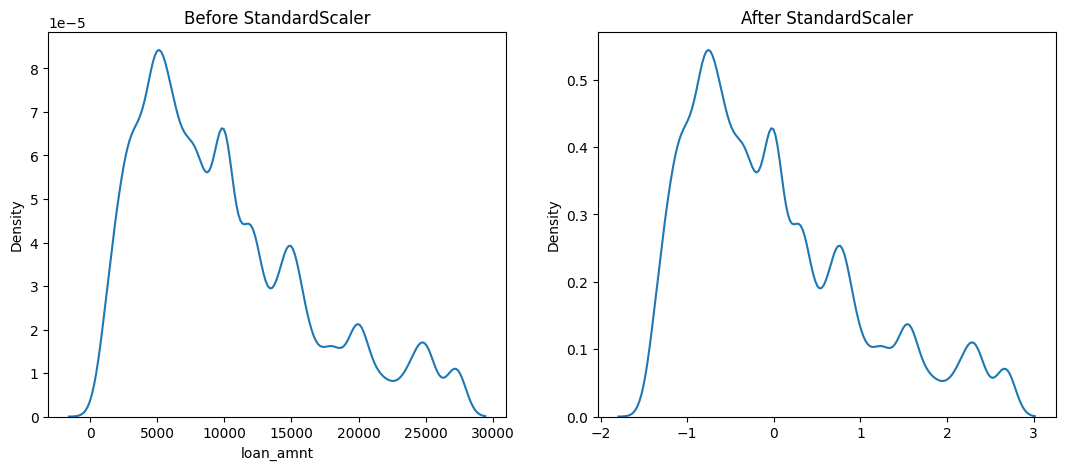

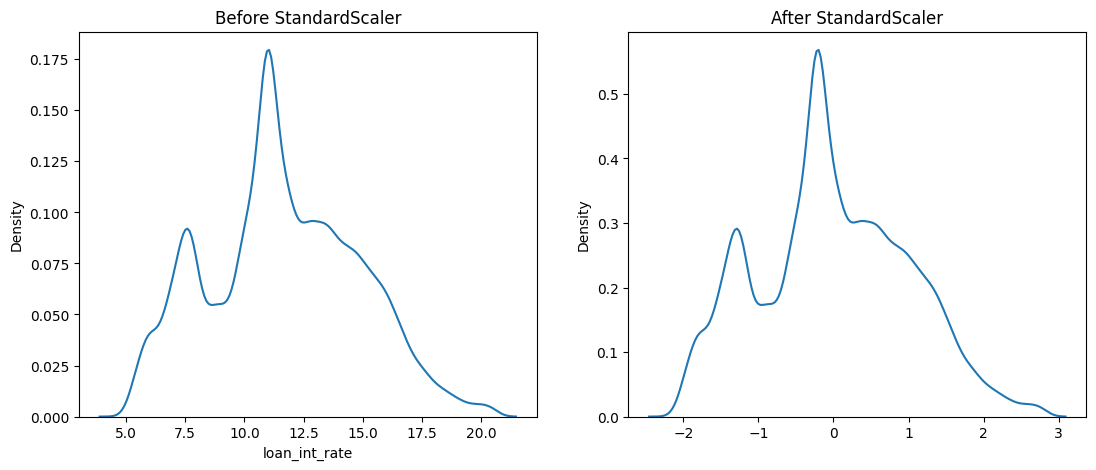

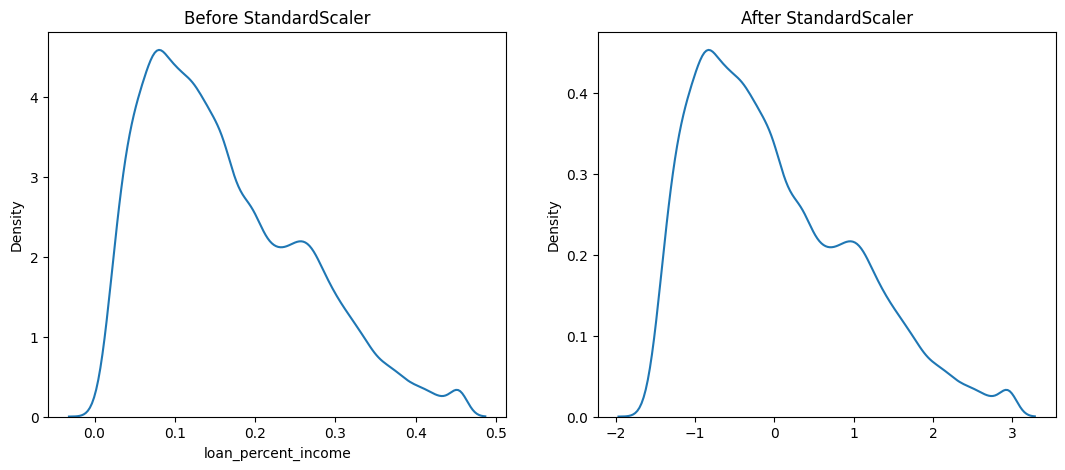

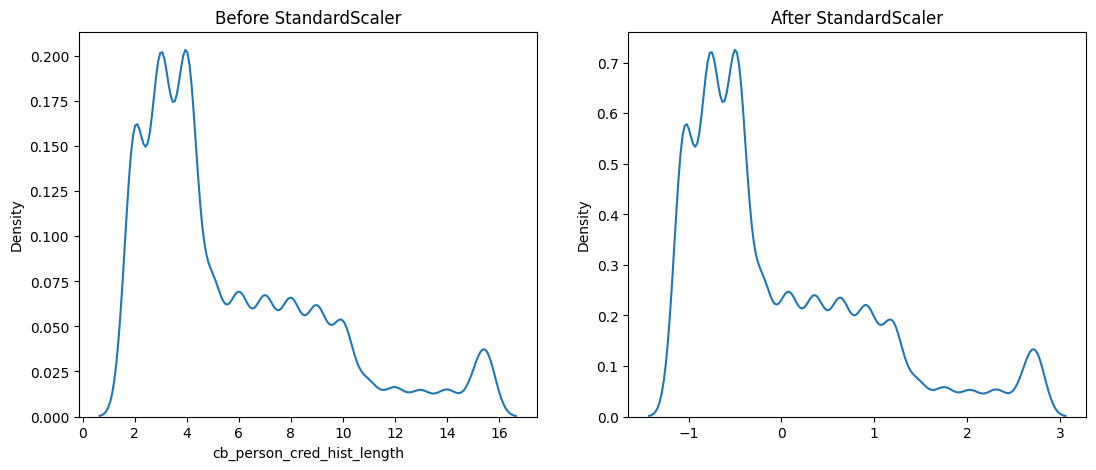

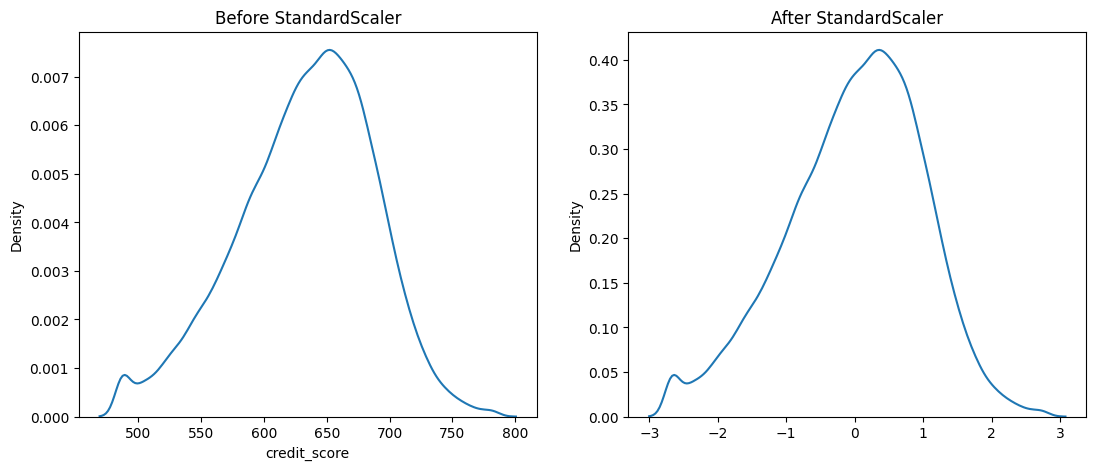

In [40]:
for col in num_cols:
    plots(X, col, StandardScaler())

# Step 05: Feature Selection

In [41]:
#Classification Problem

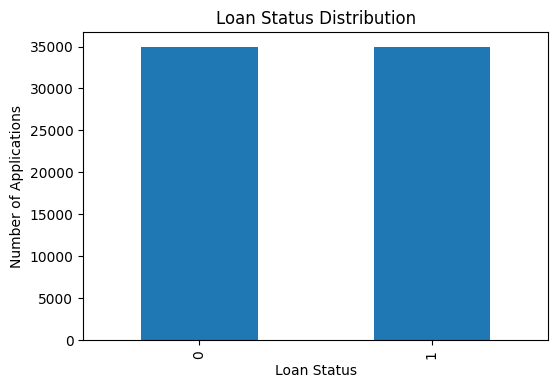

In [42]:
categorical_cols = [col for col in df_scaled.columns if df_scaled[col].dtype == 'object']
x_encoded = pd.get_dummies(df_scaled, columns=categorical_cols, drop_first=True)

counts = data[Target_column].value_counts()

# Bar Chart
plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.show()

In [43]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

In [44]:
k=6
fs = SelectKBest(score_func = mutual_info_classif, k=k)
fs.fit(df_scaled,Y)

,score_func,<function mut...001C483E0EFC0>
,k,6


In [45]:
fs.scores_

array([0.33748825, 0.11883075, 0.26305575, 0.25555937, 0.34616005,
       0.40063207, 0.33863316, 0.33765649])

In [46]:
mi_score = pd.Series(fs.scores_, index=df_scaled.columns)
mi_score

person_age                    0.337488
person_income                 0.118831
person_emp_exp                0.263056
loan_amnt                     0.255559
loan_int_rate                 0.346160
loan_percent_income           0.400632
cb_person_cred_hist_length    0.338633
credit_score                  0.337656
dtype: float64

<Axes: >

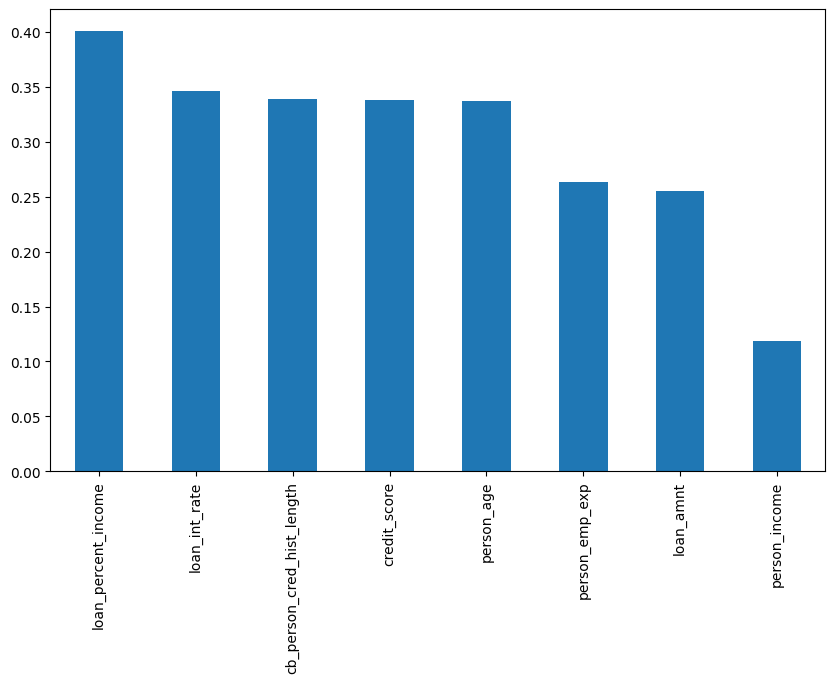

In [47]:
mi_score.sort_values(ascending=False).plot.bar(figsize=(10, 6))

In [48]:
# 1. Sort the combined MI scores in descending order
mi_score_combined_sorted = mi_score.sort_values(ascending=False)

# 2. Select top k features (e.g., top 10)
top_features = mi_score_combined_sorted.head(k).index

In [49]:
selected_df_new = df_scaled[top_features]

In [50]:
selected_df_new

,loan_percent_income,loan_int_rate,cb_person_cred_hist_length,credit_score,person_age,person_emp_exp
0,1.000000,0.715620,0.087589,0.250733,0.148980,0.000000
1,0.175824,0.401104,0.014596,0.058291,0.100920,0.000000
2,0.967033,0.512603,0.087589,0.500570,0.293160,0.162162
3,0.967033,0.664705,0.014596,0.635617,0.197040,0.000000
4,1.000000,0.602833,0.160582,0.335137,0.245100,0.054054
...,...,...,...,...,...,...
69995,0.777581,0.227458,0.165320,0.472239,0.344102,0.054675
69996,0.144248,0.991745,0.558943,0.328525,0.577253,0.553823
69997,0.184117,0.236802,0.101079,0.566811,0.174972,0.000000
69998,0.465561,0.434756,0.264674,0.495535,0.468625,0.439252


In [51]:
all_columns = ['loan_percent_income', 'loan_int_rate', 'person_income', 'loan_amnt',
        'credit_score', 'cb_person_cred_hist_length', 'person_education', 'person_home_ownership', 'loan_intent'] 

In [52]:
all_columns

['loan_percent_income',
 'loan_int_rate',
 'person_income',
 'loan_amnt',
 'credit_score',
 'cb_person_cred_hist_length',
 'person_education',
 'person_home_ownership',
 'loan_intent']

In [53]:
# Combine numeric (normalized) and categorical (one-hot encoded) features
X_full = pd.concat([selected_df_new, ohtransform, data['person_gender'], data['previous_loan_defaults_on_file']], axis=1)

In [54]:
X_full

,loan_percent_income,loan_int_rate,cb_person_cred_hist_length,credit_score,person_age,person_emp_exp,person_education_Associate,person_education_Bachelor,person_education_Doctorate,person_education_High School,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender,previous_loan_defaults_on_file
0,1.000000,0.715620,0.087589,0.250733,0.148980,0.000000,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0
1,0.175824,0.401104,0.014596,0.058291,0.100920,0.000000,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1
2,0.967033,0.512603,0.087589,0.500570,0.293160,0.162162,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
3,0.967033,0.664705,0.014596,0.635617,0.197040,0.000000,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
4,1.000000,0.602833,0.160582,0.335137,0.245100,0.054054,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0.777581,0.227458,0.165320,0.472239,0.344102,0.054675,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0
69996,0.144248,0.991745,0.558943,0.328525,0.577253,0.553823,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0
69997,0.184117,0.236802,0.101079,0.566811,0.174972,0.000000,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
69998,0.465561,0.434756,0.264674,0.495535,0.468625,0.439252,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1,0


# Split the data

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_full, Y, test_size=0.20)

In [56]:
X_train.shape

(56000, 23)

In [57]:
X_test.shape

(14000, 23)

# Logistic Regression - IT24103535

In [58]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [59]:
lr.score(X_test, y_test)

0.883

## Hyperparameter Tuning - GridSearchCV (Logistic Regression)

In [60]:
from sklearn.model_selection import GridSearchCV

# Grid 1
param_grid_log_1 = {
     'C': [0.01, 0.1], 
    'max_iter': [100, 200],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

# Grid 2
param_grid_log_2 = {
     'C': [1, 10], 
    'max_iter': [500, 1000],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

# Grid 3
param_grid_log_3 = {
     'C': [50, 100], 
    'max_iter': [1500, 2000],
    'penalty': ['l1'],
    'solver': ['saga']
}

In [61]:
# Grid 1
grid_logreg_1 = GridSearchCV(estimator=lr, param_grid=param_grid_log_1, cv = 10)
grid_logreg_1.fit(X_train, y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 0.1], 'max_iter': [100, 200], 'penalty': ['l2'], 'solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [62]:
grid_logreg_1.best_params_

{'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}

In [63]:
grid_logreg_1.score(X_test, y_test)

0.8844285714285715

In [64]:
#Grid 2
grid_logreg_2 = GridSearchCV(estimator=lr, param_grid=param_grid_log_2, cv = 10)
grid_logreg_2.fit(X_train, y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [1, 10], 'max_iter': [500, 1000], 'penalty': ['l2'], 'solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [65]:
grid_logreg_2.best_params_

{'C': 1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}

In [66]:
grid_logreg_2.score(X_test, y_test)

0.8847142857142857

In [67]:
# Grid 3
grid_logreg_3 = GridSearchCV(estimator=lr, param_grid=param_grid_log_3, cv = 10)
grid_logreg_3.fit(X_train, y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [50, 100], 'max_iter': [1500, 2000], 'penalty': ['l1'], 'solver': ['saga']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [68]:
grid_logreg_3.best_params_

{'C': 50, 'max_iter': 1500, 'penalty': 'l1', 'solver': 'saga'}

In [69]:
grid_logreg_3.score(X_test, y_test)

0.8850714285714286

In [70]:
# Evaluation Metrics

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# List of trained GridSearchCV models
grids = [grid_logreg_1, grid_logreg_2, grid_logreg_3]
grid_names = ["Logistic Grid 1", "Logistic Grid 2", "Logistic Grid 3"]

# Prepare empty list to store results
results = []

for name, grid in zip(grid_names, grids):
    y_pred = grid.predict(X_test)   # Predict on test set
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])

# Create DataFrame
df_log = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])

# Display
df_log

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Grid 1,0.884429,0.911394,0.853146,0.881309
1,Logistic Grid 2,0.884714,0.908721,0.856839,0.882018
2,Logistic Grid 3,0.885071,0.908790,0.857549,0.882426


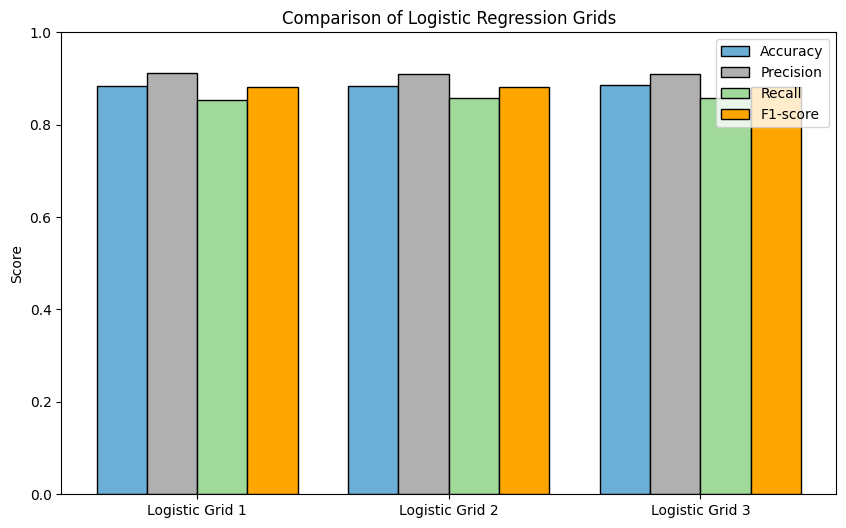

In [72]:
plt.figure(figsize=(10,6))

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = range(len(df_log))
width = 0.2

# Define different colors for each metric
colors = ['#6BAED6', '#B0B0B0', '#A1D99B', 'orange']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar([p + width*i for p in x], df_log[metric], width=width, label=metric, color=color, edgecolor='black')

plt.xticks([p + 1.5*width for p in x], df_log["Model"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparison of Logistic Regression Grids")
plt.legend()
plt.show()

# SVM - IT24103517

In [88]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [89]:
svm.score(X_test, y_test)

0.8861428571428571

## Hyperparameter Tuning - GridSearchCV (SVM)

In [146]:
# Grid 1
param_grid_svm_1 = {
    'C': [0.01, 0.1],         
    'kernel': ['linear'],      
    'gamma': ['scale']
}

# Grid 2
param_grid_svm_2 = {
    'C': [1, 10],              
    'kernel': ['linear', 'rbf'], 
    'gamma': ['scale', 'auto']
}

# Grid 3
param_grid_svm_3 = {
    'C': [50, 100],            
    'kernel': ['rbf'],         
    'gamma': ['scale', 'auto']
}

In [147]:
# Grid 1
grid_search_svm_1 = GridSearchCV(SVC(), param_grid_svm_1, cv=5, scoring='accuracy')
grid_search_svm_1.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1], 'gamma': ['scale'], 'kernel': ['linear']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


In [148]:
grid_search_svm_1.best_params_

{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

In [149]:
grid_search_svm_1.score(X_test, y_test)

0.8791428571428571

In [151]:
# Grid 2
grid_search_svm_2 = GridSearchCV(SVC(), param_grid_svm_2, cv=5, scoring='accuracy')
grid_search_svm_2.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [152]:
grid_search_svm_2.best_params_

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

In [153]:
grid_search_svm_2.score(X_test, y_test)

0.8868571428571429

In [154]:
# Grid 3
grid_search_svm_3 = GridSearchCV(SVC(), param_grid_svm_3, cv=5, scoring='accuracy')
grid_search_svm_3.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [50, 100], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [155]:
grid_search_svm_3.best_params_

{'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}

In [156]:
grid_search_svm_3.score(X_test, y_test)

0.8879285714285714

In [ ]:
# Evaluation Metrics

In [177]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# List of trained GridSearchCV models
grids = [grid_search_svm_1, grid_search_svm_2, grid_search_svm_3]
grid_names = ["SVM Grid 1", "SVM Grid 2", "SVM Grid 3"]

# Prepare empty list to store results
results = []

for name, grid in zip(grid_names, grids):
    y_pred = grid.predict(X_test)   # Predict on test set
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])

# Create DataFrame
df_svm = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])

# Display
df_svm

,Model,Accuracy,Precision,Recall,F1-score
0,SVM Grid 1,0.879143,0.910310,0.841813,0.874722
1,SVM Grid 2,0.886857,0.903461,0.866895,0.884800
2,SVM Grid 3,0.887929,0.908396,0.863474,0.885366


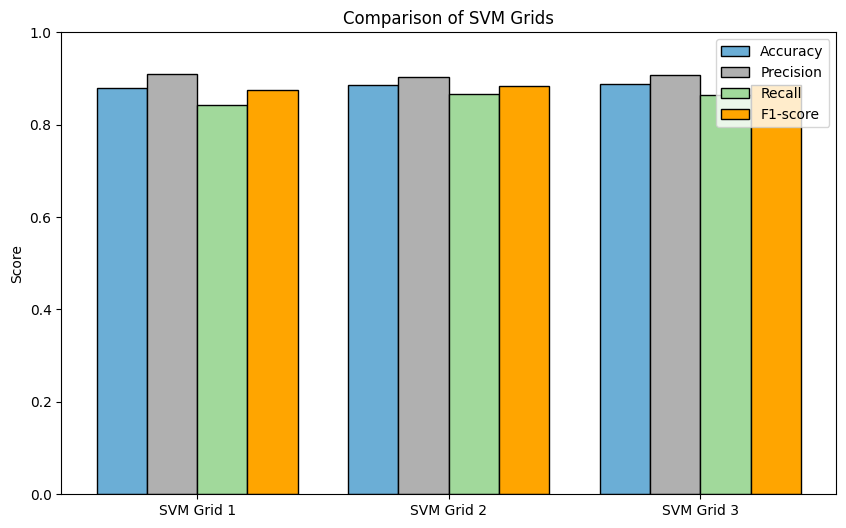

In [280]:
plt.figure(figsize=(10,6))

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = range(len(df_svm))
width = 0.2

# Define different colors for each metric
colors = ['#6BAED6', '#B0B0B0', '#A1D99B', 'orange']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar([p + width*i for p in x], df_svm[metric], width=width, label=metric, color=color, edgecolor='black')

plt.xticks([p + 1.5*width for p in x], df_svm["Model"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparison of SVM Grids")
plt.legend()
plt.show()

# Decision Tree - IT24103569

In [181]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [182]:
dt.score(X_test, y_test)

0.8843571428571428

## Hyperparameter Tuning - GridSearchCV (Decision Tree)

In [183]:
# Grid 1
param_grid_dt_1 = {
    'max_depth': [3],                
    'min_samples_split': [10],    
    'criterion': ['gini']
}

# Grid 2
param_grid_dt_2 = {
    'max_depth': [5, 10],            
    'min_samples_split': [2, 5],     
    'criterion': ['gini', 'entropy']
}

# Grid 3
param_grid_dt_3 = {
    'max_depth': [None, 15, 20],     
    'min_samples_split': [2, 3],    
    'criterion': ['entropy', 'gini']
}

In [184]:
# Grid 1
grid_dt_1 = GridSearchCV(estimator=dt, param_grid=param_grid_dt_1, cv=10)
grid_dt_1.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini'], 'max_depth': [3], 'min_samples_split': [10]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [185]:
grid_dt_1.best_params_

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 10}

In [186]:
grid_dt_1.score(X_test, y_test)

0.8302142857142857

In [187]:
# Grid 2
grid_dt_2 = GridSearchCV(estimator=dt, param_grid=param_grid_dt_2, cv=10)
grid_dt_2.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10], 'min_samples_split': [2, 5]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [188]:
grid_dt_2.best_params_

{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 5}

In [189]:
grid_dt_2.score(X_test, y_test)

0.8896428571428572

In [190]:
# Grid 3
grid_dt_3 = GridSearchCV(estimator=dt, param_grid=param_grid_dt_3, cv=10)
grid_dt_3.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['entropy', 'gini'], 'max_depth': [None, 15, ...], 'min_samples_split': [2, 3]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [191]:
grid_dt_3.best_params_

{'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 3}

In [192]:
grid_dt_3.score(X_test, y_test)

0.8948571428571429

In [ ]:
# Evaluation Metrics

In [196]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# List of trained GridSearchCV models
grids = [grid_dt_1, grid_dt_2, grid_dt_3]
grid_names = ["Desicion Tree Grid 1", "Desicion Tree Grid 2", "Desicion Tree Grid 3"]

# Prepare empty list to store results
results = []

for name, grid in zip(grid_names, grids):
    y_pred = grid.predict(X_test)   # Predict on test set
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])

# Create DataFrame
df_dt = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])

# Display
df_dt

,Model,Accuracy,Precision,Recall,F1-score
0,Desicion Tree Grid 1,0.830214,0.775012,0.931737,0.846179
1,Desicion Tree Grid 2,0.889643,0.865775,0.922902,0.893426
2,Desicion Tree Grid 3,0.894857,0.874612,0.922474,0.897905


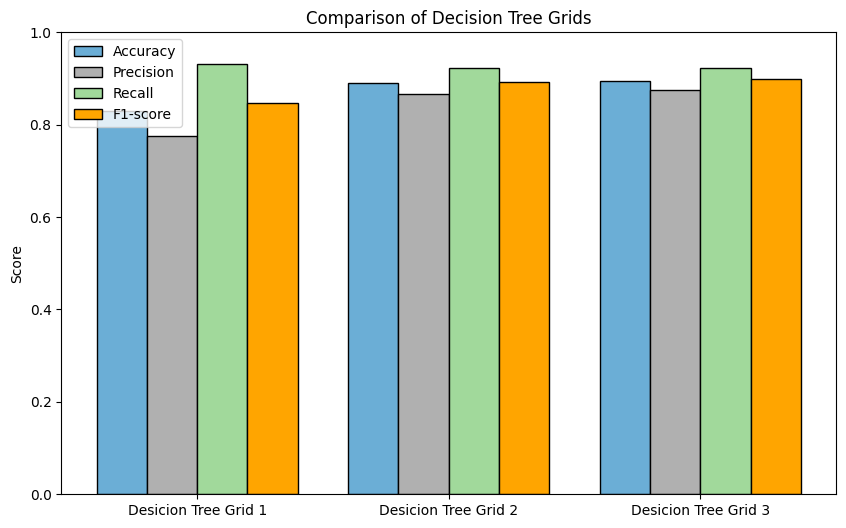

In [279]:
plt.figure(figsize=(10,6))

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = range(len(df_dt))
width = 0.2

# Define different colors for each metric
colors = ['#6BAED6', '#B0B0B0', '#A1D99B', 'orange']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar([p + width*i for p in x], df_dt[metric], width=width, label=metric, color=color, edgecolor='black')

plt.xticks([p + 1.5*width for p in x], df_dt["Model"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparison of Decision Tree Grids")
plt.legend()
plt.show()

# KNN - IT24103555

In [61]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [62]:
knn.score(X_test, y_test)

0.8767857142857143

In [63]:
correct_sum = []
for i in range(1,20):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    correct = np.sum(pred == y_test)
    correct_sum.append(correct)

In [64]:
correct_sum 

[np.int64(11910),
 np.int64(12019),
 np.int64(12133),
 np.int64(12163),
 np.int64(12220),
 np.int64(12230),
 np.int64(12252),
 np.int64(12237),
 np.int64(12275),
 np.int64(12263),
 np.int64(12297),
 np.int64(12295),
 np.int64(12293),
 np.int64(12286),
 np.int64(12283),
 np.int64(12266),
 np.int64(12302),
 np.int64(12274),
 np.int64(12284)]

## Hyperparameter Tuning - GridSearchCV (KNN)

In [63]:
# Grid 1
param_grid_knn_1 = {
    'n_neighbors': [11, 21, 31, 41, 51],           
    'weights': ['uniform'],         
    'metric': ['manhattan', 'euclidean'] 
}

# Grid 2
param_grid_knn_2 = {
    'n_neighbors': [61, 81, 101, 151, 201],    
    'weights': ['uniform', 'distance'], 
    'metric': ['euclidean', 'manhattan']
}

# Grid 3
param_grid_knn_3 = {
    'n_neighbors': [251, 301, 401, 501],       
    'weights': ['uniform', 'distance'],    
    'metric': ['manhattan', 'euclidean']
}

In [64]:
# Grid 1
grid_knn_1 = GridSearchCV(estimator=knn, param_grid=param_grid_knn_1, cv=10)
grid_knn_1.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['manhattan', 'euclidean'], 'n_neighbors': [11, 21, ...], 'weights': ['uniform']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,21


In [65]:
grid_knn_1.best_params_

{'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'uniform'}

In [66]:
grid_knn_1.score(X_test, y_test)

0.8750714285714286

In [67]:
# Grid 2
grid_knn_2 = GridSearchCV(estimator=knn, param_grid=param_grid_knn_2, cv=10)
grid_knn_2.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [61, 81, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,61


In [68]:
grid_knn_2.best_params_

{'metric': 'euclidean', 'n_neighbors': 61, 'weights': 'distance'}

In [69]:
grid_knn_2.score(X_test, y_test)

0.873

In [70]:
# Grid 3
grid_knn_3 = GridSearchCV(estimator=knn, param_grid=param_grid_knn_3, cv=10)
grid_knn_3.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['manhattan', 'euclidean'], 'n_neighbors': [251, 301, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,501


In [71]:
grid_knn_3.best_params_

{'metric': 'manhattan', 'n_neighbors': 501, 'weights': 'distance'}

In [72]:
grid_knn_3.score(X_test, y_test)

0.8538571428571429

In [73]:
# Evaluation Metrics

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# List of trained GridSearchCV models
grids = [grid_knn_1, grid_knn_2, grid_knn_3]
grid_names = ["KNN Grid 1", "KNN Grid 2", "KNN Grid 3"]

# Prepare empty list to store results
results = []

for name, grid in zip(grid_names, grids):
    y_pred = grid.predict(X_test)   # Predict on test set
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])

# Create DataFrame
df_knn = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])

# Display
df_knn

,Model,Accuracy,Precision,Recall,F1-score
0,KNN Grid 1,0.875071,0.890669,0.855758,0.872865
1,KNN Grid 2,0.873000,0.906298,0.832668,0.867925
2,KNN Grid 3,0.853857,0.872229,0.829960,0.850570


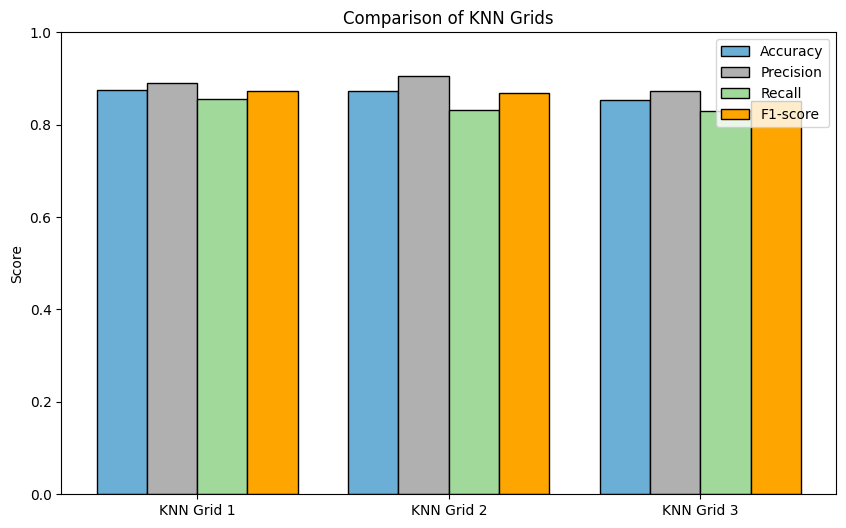

In [75]:
plt.figure(figsize=(10,6))

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = range(len(df_knn))
width = 0.2

# Define different colors for each metric
colors = ['#6BAED6', '#B0B0B0', '#A1D99B', 'orange']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar([p + width*i for p in x], df_knn[metric], width=width, label=metric, color=color, edgecolor='black')

plt.xticks([p + 1.5*width for p in x], df_knn["Model"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparison of KNN Grids")
plt.legend()
plt.show()

# Random Forest - IT24103504

In [63]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
rf.score(X_test, y_test)

0.9102857142857143

## Hyperparameter Tuning - GridSearchCV(Random Forest)

In [68]:
from sklearn.model_selection import GridSearchCV
# Grid 1
param_grid_rf_1 = {
    'n_estimators': [10, 30, 50],  
    'max_features': ['log2'] 
}

# Grid 2
param_grid_rf_2 = {
    'n_estimators': [100, 150],     
    'max_features': ['sqrt', 'log2']
}

# Grid 3
param_grid_rf_3 = {
    'n_estimators': [200, 300, 500],
    'max_features': ['sqrt', 'log2'] 
}

In [69]:
# Grid 1
grid_search_rf_1 = GridSearchCV(estimator=rf, param_grid=param_grid_rf_1, cv=10)
grid_search_rf_1.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_features': ['log2'], 'n_estimators': [10, 30, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [70]:
grid_search_rf_1.best_params_

{'max_features': 'log2', 'n_estimators': 50}

In [71]:
grid_search_rf_1.score(X_test, y_test)

0.9117142857142857

In [72]:
# Grid 2
grid_search_rf_2 = GridSearchCV(estimator=rf, param_grid=param_grid_rf_2, cv=10)
grid_search_rf_2.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 150]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,150


In [73]:
grid_search_rf_2.best_params_

{'max_features': 'sqrt', 'n_estimators': 150}

In [74]:
grid_search_rf_2.score(X_test, y_test)

0.91

In [75]:
# Grid 3
grid_search_rf_3 = GridSearchCV(estimator=rf, param_grid=param_grid_rf_3, cv=10)
grid_search_rf_3.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_features': ['sqrt', 'log2'], 'n_estimators': [200, 300, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [76]:
grid_search_rf_3.best_params_

{'max_features': 'log2', 'n_estimators': 300}

In [77]:
grid_search_rf_3.score(X_test, y_test)

0.911

In [78]:
# Evaluation Metrics

In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# List of trained GridSearchCV models
grids = [grid_search_rf_1, grid_search_rf_2, grid_search_rf_3]
grid_names = ["Random Forest Grid 1", "Random Forest Grid 2", "Random Forest Grid 3"]

# Prepare empty list to store results
results = []

for name, grid in zip(grid_names, grids):
    y_pred = grid.predict(X_test)   # Predict on test set
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])

# Create DataFrame
df_rf = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])

# Display
df_rf

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest Grid 1,0.911714,0.914355,0.909414,0.911878
1,Random Forest Grid 2,0.910000,0.909827,0.911121,0.910473
2,Random Forest Grid 3,0.911000,0.910704,0.912258,0.911481


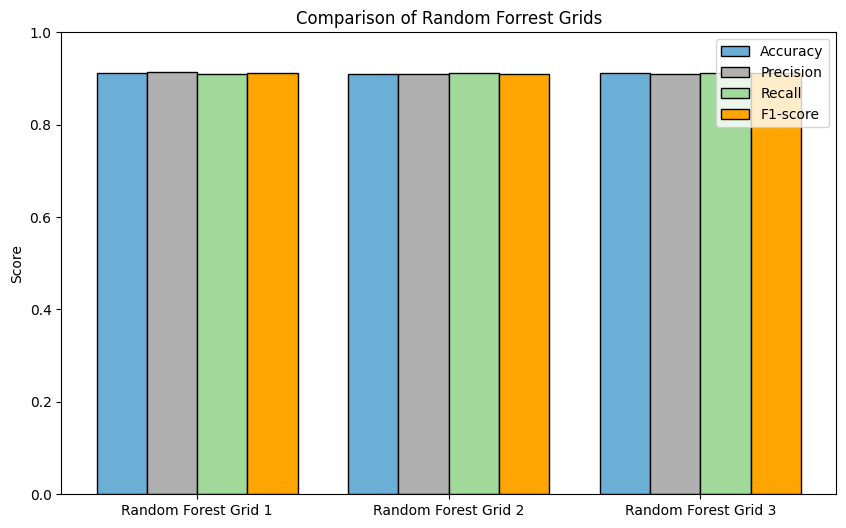

In [80]:
plt.figure(figsize=(10,6))

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = range(len(df_rf))
width = 0.2

# Define different colors for each metric
colors = ['#6BAED6', '#B0B0B0', '#A1D99B', 'orange']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar([p + width*i for p in x], df_rf[metric], width=width, label=metric, color=color, edgecolor='black')

plt.xticks([p + 1.5*width for p in x], df_rf["Model"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparison of Random Forrest Grids")
plt.legend()
plt.show()

# Multi-Layer Perceptron (MLP) Neural Network - IT24103554

In [243]:
from sklearn.neural_network import MLPClassifier

In [244]:
mlp = MLPClassifier(
    max_iter=500,
    early_stopping=True, # stop if validation score doesn't improve
    validation_fraction=0.1, # use 10% of training data for validation
    n_iter_no_change=10, # Stop if no improvement in 10 iterations
    random_state=42
)
mlp.fit(X_train, y_train)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [245]:
mlp.score(X_train, y_train)

0.8953571428571429

## Hyperparameter Tuning - GridSearchCV (MLP)

In [246]:
# Grid 1
param_grid_mlp_1 = {
    'hidden_layer_sizes': [(30,), (50,)],   
    'activation': ['tanh'],                
    'alpha': [0.01, 0.1],                
    'learning_rate_init': [0.0001]
}

# Grid 2
param_grid_mlp_2 = {
    'hidden_layer_sizes': [(50,), (100,), (50,50)], 
    'activation': ['relu', 'tanh'],         
    'alpha': [0.001, 0.0001],              
    'learning_rate_init': [0.001] 
}

# Grid 3
param_grid_mlp_3 = {
    'hidden_layer_sizes': [(100,), (100,50), (150,100)], 
    'activation': ['relu'],                 
    'alpha': [0.0001],                   
    'learning_rate_init': [0.005, 0.01]  
}

In [247]:
# Grid 1
grid_search_mlp_1 = GridSearchCV(estimator=mlp, param_grid=param_grid_mlp_1, cv=10)
grid_search_mlp_1.fit(X_train, y_train)

,estimator,MLPClassifier...ndom_state=42)
,param_grid,"{'activation': ['tanh'], 'alpha': [0.01, 0.1], 'hidden_layer_sizes': [(30,), (50,)], 'learning_rate_init': [0.0001]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(30,)"


In [248]:
grid_search_mlp_1.best_params_

{'activation': 'tanh',
 'alpha': 0.1,
 'hidden_layer_sizes': (30,),
 'learning_rate_init': 0.0001}

In [249]:
grid_search_mlp_1.score(X_test, y_test)

0.8793571428571428

In [250]:
# Grid 2
grid_search_mlp_2 = GridSearchCV(estimator=mlp, param_grid=param_grid_mlp_2, cv=10)
grid_search_mlp_2.fit(X_train, y_train)

,estimator,MLPClassifier...ndom_state=42)
,param_grid,"{'activation': ['relu', 'tanh'], 'alpha': [0.001, 0.0001], 'hidden_layer_sizes': [(50,), (100,), ...], 'learning_rate_init': [0.001]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(50, ...)"


In [251]:
grid_search_mlp_2.best_params_

{'activation': 'relu',
 'alpha': 0.0001,
 'hidden_layer_sizes': (50, 50),
 'learning_rate_init': 0.001}

In [252]:
grid_search_mlp_2.score(X_test, y_test)

0.8890714285714286

In [253]:
# Grid 3
grid_search_mlp_3 = GridSearchCV(estimator=mlp, param_grid=param_grid_mlp_3, cv=10)
grid_search_mlp_3.fit(X_train, y_train)

,estimator,MLPClassifier...ndom_state=42)
,param_grid,"{'activation': ['relu'], 'alpha': [0.0001], 'hidden_layer_sizes': [(100,), (100, ...), ...], 'learning_rate_init': [0.005, 0.01]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(100, ...)"


In [254]:
grid_search_mlp_3.best_params_

{'activation': 'relu',
 'alpha': 0.0001,
 'hidden_layer_sizes': (100, 50),
 'learning_rate_init': 0.01}

In [255]:
grid_search_mlp_3.score(X_test, y_test)

0.8852857142857142

In [256]:
# Evaluation Metrics

In [257]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# List of trained GridSearchCV models
grids = [grid_search_mlp_1, grid_search_mlp_2, grid_search_mlp_3]
grid_names = ["MLP Grid 1", "MLP Grid 2", "MLP Grid 3"]

# Prepare empty list to store results
results = []

for name, grid in zip(grid_names, grids):
    y_pred = grid.predict(X_test)   # Predict on test set
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])

# Create DataFrame
df_mlp = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])

# Display
df_mlp

,Model,Accuracy,Precision,Recall,F1-score
0,MLP Grid 1,0.879357,0.909342,0.843380,0.875120
1,MLP Grid 2,0.889071,0.903664,0.871598,0.887341
2,MLP Grid 3,0.885286,0.909366,0.856491,0.882137


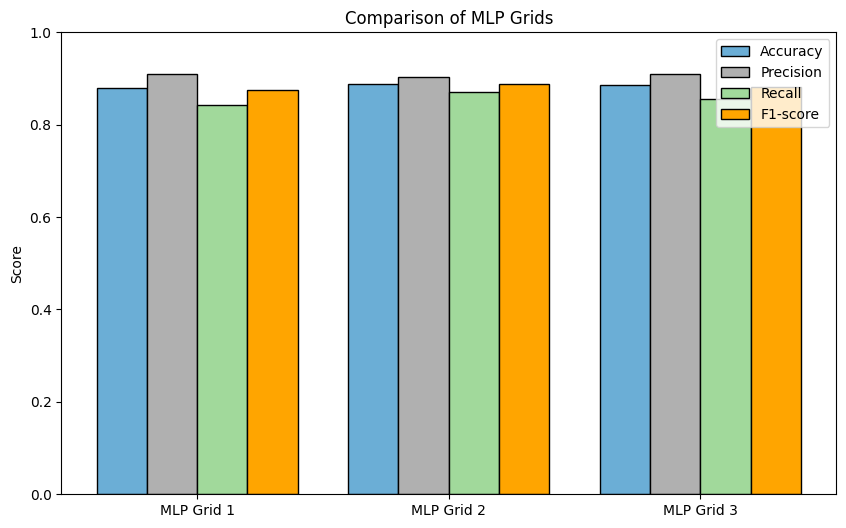

In [276]:
plt.figure(figsize=(10,6))

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = range(len(df_mlp))
width = 0.2

# Define different colors for each metric
colors = ['#6BAED6', '#B0B0B0', '#A1D99B', 'orange']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar([p + width*i for p in x], df_mlp[metric], width=width, label=metric, color=color, edgecolor='black')

plt.xticks([p + 1.5*width for p in x], df_mlp["Model"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparison of MLP Grids")
plt.legend()
plt.show()

# Evaluation Metrics

In [259]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [265]:
models = {
    "Logistic Regression": grid_logreg_1,
    "Decision Tree": grid_dt_3,
    "Random Forest": grid_search_rf_3,
    "SVM": grid_search_svm_3,
    "KNN" : grid_knn_3,
    "MLP" : grid_search_mlp_2
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, acc, prec, rec, f1])

In [266]:
df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.879214,0.912996,0.838963,0.874415
1,Decision Tree,0.895071,0.875169,0.922189,0.898064
2,Random Forest,0.910500,0.915633,0.904803,0.910186
3,SVM,0.887929,0.908396,0.863474,0.885366
4,KNN,0.875286,0.887973,0.859627,0.873570
5,MLP,0.889071,0.903664,0.871598,0.887341


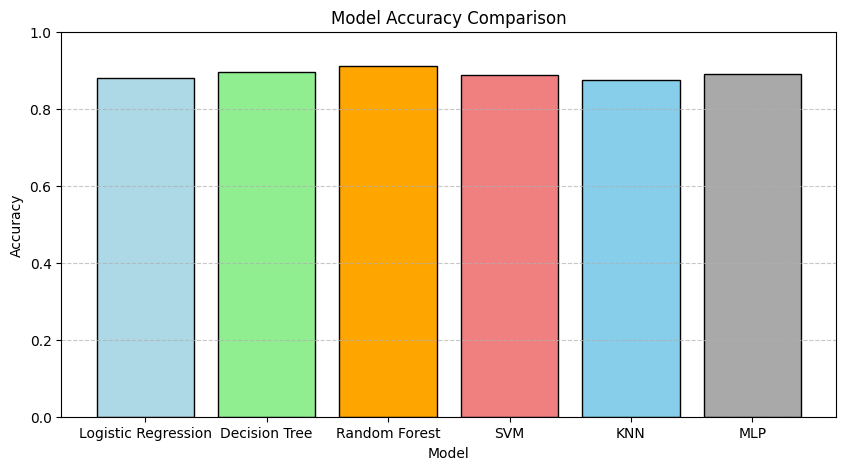

In [289]:
plt.figure(figsize=(10, 5))
plt.bar(df["Model"], df["Accuracy"], color=["lightblue", "lightgreen", "orange", "lightcoral", "skyblue", "#a9a9a9"], edgecolor='black')
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Best One - Random Forest

In [85]:
# Example row data
row_data = {
    "loan_percent_income": 11.14,
    "loan_int_rate": 0.08,
    "cb_person_cred_hist_length": 2.0,
    "credit_score": 504.0,
    "person_age": 21.0,
    "person_emp_exp": 0.0,
    "person_education_Associate": 0,
    "person_education_Bachelor": 0,
    "person_education_Master": 0,
    "person_education_Doctorate": 0,
    "person_education_High School": 1,
    "person_home_ownership_OWN": 1,
    "person_home_ownership_RENT": 0,
    "person_home_ownership_MORTGAGE": 0,
    "person_home_ownership_OTHER": 0,
    "loan_intent_DEBTCONSOLIDATION": 0,
    "loan_intent_EDUCATION": 1,
    "loan_intent_HOMEIMPROVEMENT": 0,
    "loan_intent_MEDICAL": 0,
    "loan_intent_PERSONAL": 0,
    "loan_intent_VENTURE": 0,
    "person_gender": 0,   # female
    "previous_loan_defaults_on_file": 0
}

# Convert to DataFrame
new_input = pd.DataFrame([row_data])

# Reorder columns to match X_full
new_input = new_input[X_full.columns]

# Predict
proba = grid_search_rf_3.predict_proba(new_input)
print("Probability of Reject/Approve:", proba)

prediction = grid_search_rf_3.predict(new_input)
print("Predicted output:", prediction)

Probability of Reject/Approve: [[0.11333333 0.88666667]]
Predicted output: [1]
